# Notebook 05a: Signed-laterality decodability probe (Idea 5, core arm)

## The single question this notebook answers

This is the core, zero-retrain arm of research idea 5,
[signed-laterality-decodability](notes/ideas-claude/05-signed-laterality-decodability/README.md).
It asks exactly one falsifiable question:

> On source-video-disjoint folds, is a signed left-minus-right laterality axis linearly decodable
> from the frozen S-JEPA token tensor above a raw-coordinate null by a pre-registered margin, and
> does the anatomical mirror that swaps left and right landmarks negate the decoded scalar?

Every design choice below follows from that one sentence, so it is worth reading twice.

## Nothing here retrains the encoder

This is the point most easily missed, and it changes how every later number should be read. The
encoder is **frozen**: its weights are loaded from a finished checkpoint and are never updated
anywhere in this notebook. Each of the four comparison routes, which are called **lanes**, is a
test-time linear read of frozen target-encoder tokens. So when a lane scores badly, that is a
statement about what the frozen representation makes *linearly available*, and not a statement
about how well the encoder could have been trained.

## What the reader is assumed to have

- A finished S-JEPA curriculum checkpoint plus the pose cache it was trained on. Section 0 resolves
  where both live, and section 4 binds to them.
- No machine-learning background. The next cell, the reader's guide, defines every term used here
  before that term is needed.

## What this notebook produces

1. Four lane scores measured on identical source-video-disjoint folds (section 7).
2. One mirror-equivariance slope (section 8).
3. One verdict, from a decision rule fixed before any number was seen (section 9).
4. Two figures (section 10) and one machine-readable JSON bundle (section 11).

## How to walk it

The notebook has fourteen numbered sections, 0 through 13, meant to be read in order. Sections 0
through 6 build the instrument, section 7 measures with it, sections 8 and 9 judge the measurement,
and sections 10 through 13 record and interpret it. The verdict is deliberately not revealed before
section 9, so a first-time reader can form an expectation and then check it.

## Standing disclosures that apply to every number below

- All results are **transductive**: the encoder saw every evaluation sequence during its own
  training. Nothing here is unseen-video performance.
- The **source video is the independent unit of evidence**, not the sequence. There are 18 of them.
- Folder labels such as stroke and parkinsons are **dataset annotations, not clinical diagnoses**.
- Nothing here is clinical validation.

## The two run modes

- `GAVD_MODE=real` reads the real pose cache and the real checkpoint, exactly as notebooks 05 and 06
  do. The outputs stored in this file are from a real-mode run.
- `GAVD_MODE=smoke`, the default when artifacts are absent, builds a small synthetic cohort with a
  planted sign-flipping laterality signal so that every cell still runs end to end. Smoke numbers
  are illustrative plumbing checks only, and are labelled as such wherever they appear.

## What comes next

`nb_05b_reflection_reach_and_futures` is the companion notebook. It rehearses this decision rule on
*simulated* numbers and sketches an external multi-view reach arm; it issues no verdict about the
checkpoint. The escape routes that this notebook leaves open are closed afterwards by `nb_09a`
(Idea 9 arm 1) and by the `new_nb_09_0x` series (Idea 9 arm 2).

See `notes/ideas-claude/_shared_facts.md` for the single source of truth on every number.


## Reader's guide: the vocabulary, in the order you will need it

No background in machine learning is assumed. Read this cell once and the rest of the notebook can
be read without stopping. Terms are introduced in the order the notebook uses them.

### 1. What goes in

A **pose sequence** is a short time-ordered series of body-joint coordinates: where the left wrist,
right wrist, shoulders, hips, and other landmarks sit in each video frame. A **source video** is the
recording a sequence was cut from; several sequences can come from the same source video, which is
why the source video, not the sequence, is treated as the independent unit of evidence.

### 2. What the model does with it

The **encoder** is the part of S-JEPA that turns coordinates into a long list of learned numbers.
Those numbers are called **features**, and the whole list is the **representation**. A single
feature need not have any human-readable meaning; it is simply a number the model found useful while
learning. **Frozen encoder** means those numbers come from an already-trained encoder whose weights
are not changed anywhere in this notebook.

### 3. What we try to predict

The prediction target is one **scalar**, meaning one number per pose sequence. It is **signed**:
positive and negative values stand for opposite left-versus-right directions. Calling it a
**laterality axis** means that this one number summarizes a left-minus-right movement difference.
It is not a diagnosis, and it is not a severity score.

### 4. How we try to predict it

A **linear probe**, also called a **readout** or a **decoder**, is a deliberately simple prediction
rule fitted on top of frozen features: multiply each feature by a learned weight, then add the
results together. To **decode** the target means to run that rule and get one predicted laterality
number. This simplicity is the whole point. If a linear probe succeeds, the information is easy to
read from the chosen features. If it fails, that only rules out *easy* readability; it does not
prove that no more complicated method could ever find the information.

**Ridge regression** is the specific fitting method used. It is a linear probe that also discourages
very large weights, which keeps the fit from swinging wildly when features are numerous and
correlated. The strength of that discouragement is a knob chosen inside the training data only.

### 5. What a lane is, and why there are four

A **lane** is one deliberately defined route for predicting the same target. Every lane uses the
same folds and the same ridge scoring procedure; the only thing that changes is *what information
the probe is allowed to see*. Lanes exist because a single score cannot be interpreted on its own.
Each lane is built to close one specific escape route, that is, one specific alternative explanation
for a good score:

- **Lane A, the learned-encoder probe.** This is the treatment, the claim actually under test. It
  feeds the frozen trained token features to the probe. It closes no escape route by itself; it is
  the thing the other three lanes are there to interrogate.
- **Lane B, the raw-coordinate reference.** Escape route closed: *maybe the target is not
  recoverable at all, or the scoring code is broken.* Lane B skips the network entirely and hands
  the probe handcrafted signed left-minus-right movement summaries taken straight from the
  coordinates. Because the target is built from the same family of signed excursions, Lane B is
  close to circular by construction, so a very high score is expected and is not a discovery. Treat
  it as a ceiling and a sanity check, never as a rival to Lane A.
- **Lane C, the untrained-encoder floor.** Escape route closed: *maybe any high-dimensional feature
  bundle of this shape would have scored the same, with no learning involved.* Lane C uses an
  encoder of identical architecture whose weights were randomly initialised and never trained.
  Lane A must beat Lane C for any training-specific claim to survive.
- **Lane D, the side-agnostic nuisance control.** Escape route closed: *maybe the score comes from
  an unsigned shortcut such as overall movement size, video style, or pose-detector behaviour.*
  Lane D starts from the learned tokens and then pools every joint and time step into global means
  and standard deviations, which throws away which landmark was left and which was right. A feature
  set that cannot tell left from right should not be able to recover a signed quantity, so a *high*
  Lane D score is a warning, not evidence.

### 6. How lanes are scored: R-squared, including negative values

**R-squared**, written `R²`, compares the probe against a very simple fallback: ignore every input
and always predict the average target value of the held-out data. `R² = 1` is perfect prediction.
`R² = 0` means the probe is no better than repeatedly predicting that average. **Negative R-squared**
means the probe's squared errors are *larger* than the average-only fallback's. For example, if the
true values are 1, 2, and 3, then always predicting 2 is the baseline; a model that misses by even
more than that earns a negative score. Negative here never means "negative movement" and never means
"negative correlation"; it means "worse errors than the average baseline".

**MAE**, mean absolute error, is reported alongside. It is the average size of the prediction error
in the target's own units, so it is easier to feel than R-squared but harder to compare across
targets.

### 7. How the data is split: source-video-disjoint and transductive

**Source-video-disjoint** means every sequence cut from one source video stays together: that video
either helps fit the probe or is used to score it, never both. This removes the most obvious leak,
which is the probe recognising a video it has already fitted to.

It does not remove every leak. The frozen encoder had already learned from this same corpus before
any of these probe splits existed. That situation is called **transductive**. A useful analogy: a
student studied the whole stack of flashcards, and only afterwards did the teacher pull some cards
out to make a quiz. The quiz still tests the student's final answering rule, but it says nothing
about cards from a new person or a new deck.

### 8. Why the number of columns matters: high dimensionality

**High-dimensional** means there are many candidate feature columns compared with the number of
independent examples. Here the learned lane has 1,152 feature columns while the cohort holds 96
sequences from only 18 source videos. With that shape, a flexible fit can latch onto accidental
patterns, and many columns carry nearly the same information as each other. Ridge regression damps
that problem but cannot manufacture more independent videos. This is one reason the baselines, the
held-out videos, and the fixed thresholds all matter.

### 9. How the verdict is decided: gates

A **gate** is a pass-or-fail checkpoint whose threshold was written down *before* the final result
was looked at. It works like a minimum requirement on a checklist. Three primary gates must all pass
before this notebook may call the signed axis present. Fixing them in advance is what stops anyone,
including the authors, from choosing after the fact whichever comparison happens to look best.

### 10. The mirror vocabulary

The **anatomical mirror** does two things together, and both halves matter: it reflects the body by
negating the horizontal `x` coordinate, *and* it swaps every left landmark with its right partner so
that the left knee becomes the right knee. A reflection on its own is not the anatomical mirror.

**Decoded-original** is the number produced when an ordinary pose sequence goes through the encoder
and then through the fitted Lane A readout. **Decoded-mirrored** is the number produced by the same
encoder and the *same* readout after the input has been anatomically mirrored. No new mirror-specific
readout is fitted, so the only intended difference between the two values is the mirror on the input.

If decoded-original is `+2`, a representation that genuinely encodes a signed left-minus-right axis
should give a decoded-mirrored value near `-2`. Plotting decoded-mirrored against decoded-original
across many sequences should then trace the line `y = -x`, whose slope is `-1`. This equal-size,
opposite-sign behaviour is called **antisymmetry**, and the property of a representation that obeys
it is called **reflection equivariance**.

The **mirror test** measures that slope. It is not another accuracy score: a probe can predict a
target well while relying on features that ignore the expected left/right transformation entirely.
So the mirror test asks how the information is *organized*, not whether some information is present.
A slope inside the pre-agreed band `[-1.25, -0.8]` counts as a sufficiently clean sign reversal.

### 11. The control vocabulary

A **control** is a comparison designed to catch one specific alternative explanation. A **nuisance**
is an unwanted clue, such as overall movement size, video style, or pose-detector behaviour, that
could help prediction without representing left versus right at all. Calling the nuisance control
**clean** means Lane D stayed near zero and did not trigger the pre-defined artifact warning. A clean
control removes exactly one alternative explanation. It does not make Lane A successful, and it does
not prove that every possible artifact has been eliminated.


## 0. Environment and mode

**What we do.** Resolve the project root the way notebooks 04 through 06 do, using `ALEXPOSE_ROOT`
or a `.git` plus `data/gavd` marker, load `.env`, and decide whether this run is real or smoke.

**Why this comes first.** Every later section depends on binding to *one* known checkpoint and *one*
known pose cache. Deciding that here, loudly and in print, means no later cell has to guess, and a
reader can tell at a glance which artifacts produced the numbers further down. If the real artifacts
are missing the notebook falls back to smoke mode instead of raising, so it is always runnable.

**What to look at in the output.** Four lines. `effective MODE` must read `real` for the numbers in
this file to be the measured result; it does. `ARTIFACT_ROOT` shows which artifact tree was used,
which here is the `gavd6/work/artifacts` tree named by `GAVD_ARTIFACT_DIR`, not the notebook's local
default. `checkpoint` and `pose cache` must both report `present=True`; they do.

**What we may conclude.** Only that the run is bound to real artifacts. Nothing about laterality yet.


In [1]:
from pathlib import Path
import os, sys, math, json, hashlib, copy, warnings

import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm"
try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

# Artifact locations follow the SAME env resolution as notebook 05 exactly:
#   ARTIFACT_ROOT = GAVD_ARTIFACT_DIR or TUTORIAL_DIR/work/artifacts
#   ARTIFACT_DIR  = ARTIFACT_ROOT / MODE   (checkpoints live directly here)
#   POSE_DIR      = ARTIFACT_DIR / "poses"
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()

REQUESTED_MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if REQUESTED_MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")

# Checkpoint selection mirrors notebook 05: augmented cohort is the ea59fea0 lineage.
TRUTHY = {"1", "true", "yes", "on"}
INCLUDE_AUGMENTED = os.getenv("SJEPA_INCLUDE_AUGMENTED_NORMAL", "1").strip().lower() in TRUTHY
EXPLICIT_CHECKPOINT = os.getenv("SJEPA_INSPECT_CHECKPOINT", "").strip()
CHECKPOINT_NAME = (
    "sjepa_curriculum_final_augmented.pt" if INCLUDE_AUGMENTED else "sjepa_curriculum_final.pt"
)
EXPECTED_FINGERPRINT_PREFIX = "ea59fea0"
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]


def artifact_dir_for(mode):
    return ARTIFACT_ROOT / mode


def checkpoint_path_for(mode):
    if EXPLICIT_CHECKPOINT:
        p = Path(EXPLICIT_CHECKPOINT).expanduser()
        return p if p.is_absolute() else artifact_dir_for(mode) / p
    return artifact_dir_for(mode) / CHECKPOINT_NAME


# Real mode requires BOTH the real checkpoint and the real pose cache; else fall back to smoke.
real_ckpt = checkpoint_path_for("real")
real_poses = artifact_dir_for("real") / "poses"
have_real = REQUESTED_MODE == "real" and real_ckpt.is_file() and real_poses.exists()
MODE = "real" if have_real else "smoke"
if REQUESTED_MODE == "real" and not have_real:
    warnings.warn(
        f"Requested real mode but artifacts are missing "
        f"(checkpoint={real_ckpt.is_file()}, poses={real_poses.exists()}). "
        "Falling back to smoke mode with a synthetic cohort. Smoke numbers are illustrative only."
    )

ARTIFACT_DIR = artifact_dir_for(MODE)
POSE_DIR = ARTIFACT_DIR / "poses"
CHECKPOINT_PATH = checkpoint_path_for(MODE)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

if MODE == "smoke":
    print("SMOKE MODE: hand-authored motions test code paths only. No clinical validity.")
print(f"PROJECT_ROOT      : {PROJECT_ROOT}")
print(f"ARTIFACT_ROOT     : {ARTIFACT_ROOT}")
print(f"requested mode    : {REQUESTED_MODE}")
print(f"effective MODE    : {MODE}")
print(f"checkpoint        : {CHECKPOINT_PATH}  (present={CHECKPOINT_PATH.is_file()})")
print(f"pose cache        : {POSE_DIR}  (present={POSE_DIR.exists()})")

PROJECT_ROOT      : /Users/pmui/dev/alexpose
ARTIFACT_ROOT     : /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts
requested mode    : real
effective MODE    : real
checkpoint        : /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/sjepa_curriculum_final_augmented.pt  (present=True)
pose cache        : /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/poses  (present=True)


## 1. Anatomy constants and the frozen laterality operators

**What we do.** Define the landmark constants, then freeze the two deterministic functions this
experiment is built on, before any feature or model has been touched:

- `signed_left_minus_right(coords)` is the regression target `y`. For each left/right landmark pair
  it measures how much that landmark moved over the clip, then sums left minus right across pairs.
  Positive means the left side moved more, negative means the right side moved more. Because it is
  built from per-joint standard deviations, it does not care where the body is in the frame.
- `anatomical_mirror(coords)` negates the horizontal `x` coordinate *and* swaps each left landmark
  with its right partner, over all 16 left/right pairs including face and arm, so the result is a
  valid whole-body reflection rather than a partial one.

`MASK_KEYPOINTS` is the same 12-landmark maskable whitelist the training curriculum used.
`LEFT_RIGHT_PAIRS` is the six lower-body-plus-shoulder pair list used to build the target.

**Why this comes before anything is fitted.** A target that is defined after seeing the features can
be tuned, however unintentionally, to make the answer come out. Freezing both operators here means
the target and the mirror are properties of the *data definition*, not of the model.

**What to look at in the output.** The self-check line: `original=+1.4555  mirrored=-1.4555`, then
`OK: signed_left_minus_right is antisymmetric on raw coordinates.` The assert following it is exact,
not approximate.

**What we may conclude.** That the target is antisymmetric under the anatomical mirror *by
construction*, on raw coordinates. This matters enormously for section 8: it means that if the
decoded scalar later fails to flip, the failure cannot be blamed on the target or on the mirror. It
will have to be a property of the encoder and readout in between. What we may not conclude yet is
anything about whether the encoder preserves that antisymmetry.


In [2]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER", "RIGHT_EYE_INNER", "RIGHT_EYE",
    "RIGHT_EYE_OUTER", "LEFT_EAR", "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST", "RIGHT_WRIST", "LEFT_PINKY",
    "RIGHT_PINKY", "LEFT_INDEX", "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL",
    "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

# Lower-body-plus-shoulder pairs for the SIGNED target (proposal Method, code block).
LEFT_RIGHT_PAIRS = [(11, 12), (23, 24), (25, 26), (27, 28), (29, 30), (31, 32)]

# The FULL 16-pair mirror (matches notebook 05's geometric_view flip): every left/right landmark,
# including face and arm, so the mirror is a valid whole-body reflection.
FULL_MIRROR_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10),          # eyes, ears, mouth
    (11, 12), (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),  # shoulder..thumb
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),            # hip..foot index
]


def signed_left_minus_right(coords):
    '''coords: (T, 33, 3) or (T, 33, >=3). Signed per-side excursion, left minus right.'''
    coords = np.asarray(coords, dtype=np.float64)[..., :3]
    total = 0.0
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        left_excursion = coords[:, left_idx, :].std(axis=0).sum()
        right_excursion = coords[:, right_idx, :].std(axis=0).sum()
        total += left_excursion - right_excursion
    return float(total)


def anatomical_mirror(coords, pairs=FULL_MIRROR_PAIRS):
    '''Negate x and swap each left landmark with its right partner. Preserves the visibility column
    if present so the mirrored sequence can go back through the same preprocessing.'''
    mirrored = np.asarray(coords, dtype=np.float32).copy()
    mirrored[:, :, 0] = -mirrored[:, :, 0]
    for left_idx, right_idx in pairs:
        mirrored[:, [left_idx, right_idx], :] = mirrored[:, [right_idx, left_idx], :]
    return mirrored


# Self-check: the target is antisymmetric on RAW coordinates by construction.
_demo = np.random.randn(20, 33, 3).astype(np.float32)
_orig = signed_left_minus_right(_demo)
_mir = signed_left_minus_right(anatomical_mirror(_demo))
print(f"raw-coordinate self-check:  original={_orig:+.4f}  mirrored={_mir:+.4f}  (should be near equal-and-opposite)")
assert abs(_orig + _mir) < 1e-6 * (1 + abs(_orig)), "raw target must be exactly antisymmetric"
print("OK: signed_left_minus_right is antisymmetric on raw coordinates.")

raw-coordinate self-check:  original=+1.4555  mirrored=-1.4555  (should be near equal-and-opposite)
OK: signed_left_minus_right is antisymmetric on raw coordinates.


## 2. Preprocessing (reused verbatim from notebooks 04 through 06)

**What we do.** Run the project's exact preprocessing chain: short-gap interpolation of
low-visibility joints, pelvis-centering with body-scale normalization, and a temporal resize to a
fixed frame count.

**Why it must be verbatim.** The encoder was trained on sequences shaped by this exact chain. If we
fed it anything else, a poor lane score could simply mean "the input did not look like training
data", which would be a different and much less interesting finding. Copying the chain removes that
explanation before it can be offered.

**Why the mirror arm needs a note here.** `center_and_scale` subtracts the pelvis and divides by a
body scale, and the target uses per-joint standard deviation, which is unaffected by translation. So
the signed target is well defined on raw or centered coordinates alike. The order of operations is
still deliberate: we apply the mirror to the RAW coordinate column and only then run the same
preprocessing. That way the mirrored input the encoder sees is a genuine reflection of a real
preprocessed sequence, rather than a reflection of an already normalized artefact.

**What to look at in the output.** One confirmation line that the helpers are defined. Nothing is
measured yet.

**What we may conclude.** Nothing about the hypothesis. This section only guarantees that the
encoder will be fed what it expects.


In [3]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (np.arange(1, gap + 1, dtype=np.float32) / (gap + 1))[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction)
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    both = left_ok & right_ok
    pelvis[both] = 0.5 * (left_hip[both] + right_hip[both])
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0)
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack([np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])], axis=1)
    return resized.reshape(frames, *array.shape[1:])


def prepare_sequence(raw_sequence, frames):
    '''raw_sequence: [T, 33, 4] (x, y, z, visibility). Returns (xyz [frames,33,3], valid [frames,33]).'''
    interpolated, valid = interpolate_low_visibility(raw_sequence)
    scaled = center_and_scale(interpolated)
    xyz = temporal_resize(scaled[..., :3], frames)
    valid_resized = temporal_resize(valid.astype(np.float32), frames) > 0.5
    return xyz.astype(np.float32), valid_resized


print("preprocessing helpers ready (interpolate -> center_and_scale -> temporal_resize).")

preprocessing helpers ready (interpolate -> center_and_scale -> temporal_resize).


## 3. Model classes (reused verbatim so `state_dict` keys match)

**What we do.** Paste the same `SkeletonPatchEncoder`, `SkeletonPredictor`, and `SJEPAGait`
definitions the other notebooks use, so that loading the saved weights matches key for key.

**Why this comes before loading.** The S-JEPA classes are not packaged as an importable module in
this project; every notebook pastes them inline. If a single layer name drifted, `load_state_dict`
would either fail loudly or, worse, silently leave part of the model at its random initialisation,
and the "frozen trained encoder" lane would quietly become a partly random one. To rule that out we
always construct the model as `SJEPAGait(**checkpoint["config"])`, reading whatever dimensions the
checkpoint itself stored, and never hardcoding them.

**What to look at in the output.** A single `model classes defined.` line. If PyTorch were
unavailable the cell would instead set `HAVE_TORCH=False`, and the encoder-dependent lanes would be
skipped with a clear message while the raw-coordinate lane and the target still ran.

**What we may conclude.** Only that the class definitions exist. The weights arrive next.


In [4]:
try:
    import torch
    from torch import nn
    HAVE_TORCH = True
except Exception as exc:  # pragma: no cover
    HAVE_TORCH = False
    print(f"PyTorch unavailable ({exc}); learned-encoder lanes will be skipped.")

if HAVE_TORCH:
    class SkeletonPatchEncoder(nn.Module):
        def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                     embed_dim=64, depth=2, heads=4, dropout=0.0):
            super().__init__()
            self.frames, self.joints, self.coordinate_dim = frames, joints, coordinate_dim
            self.segment_length, self.embed_dim = segment_length, embed_dim
            self.segments = frames // segment_length
            self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
            self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
            self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
            layer = nn.TransformerEncoderLayer(
                d_model=embed_dim, nhead=heads, dim_feedforward=embed_dim * 4,
                dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
            self.norm = nn.LayerNorm(embed_dim)

        def patchify(self, x):
            batch = x.shape[0]
            if x.shape[1:] != (self.frames, self.joints, self.coordinate_dim):
                raise ValueError(f"Expected [B,{self.frames},{self.joints},{self.coordinate_dim}], got {tuple(x.shape)}")
            x = x.reshape(batch, self.segments, self.segment_length, self.joints, self.coordinate_dim)
            x = x.permute(0, 1, 3, 2, 4)
            x = x.flatten(3)
            return x  # [B, segments, joints, segment_length*coordinate_dim]

        def positioned_tokens(self, x):
            tokens = self.patch_embed(self.patchify(x))
            tokens = tokens + self.time_pos[None, :, None, :] + self.joint_pos[None, None, :, :]
            return tokens

        def forward(self, x, keep_mask=None):
            tokens = self.positioned_tokens(x)
            batch = tokens.shape[0]
            flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
            encoded = self.blocks(flat)
            return self.norm(encoded)

    class SkeletonPredictor(nn.Module):
        def __init__(self, segments, joints, encoder_dim=64, predictor_dim=64, depth=2, heads=4, dropout=0.0):
            super().__init__()
            self.segments, self.joints, self.predictor_dim = segments, joints, predictor_dim
            self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
            self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
            nn.init.normal_(self.mask_token, std=0.02)
            self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
            self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
            layer = nn.TransformerEncoderLayer(
                d_model=predictor_dim, nhead=heads, dim_feedforward=predictor_dim * 4,
                dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
            self.norm = nn.LayerNorm(predictor_dim)
            self.output = nn.Linear(predictor_dim, encoder_dim)

        def forward(self, *args, **kwargs):
            raise NotImplementedError("Predictor is not needed for the frozen probe.")

    class SJEPAGait(nn.Module):
        def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                     embed_dim=64, encoder_depth=2, predictor_depth=2, heads=4):
            super().__init__()
            self.view_encoder = SkeletonPatchEncoder(
                frames, joints, coordinate_dim, segment_length, embed_dim, encoder_depth, heads)
            self.target_encoder = copy.deepcopy(self.view_encoder)
            for parameter in self.target_encoder.parameters():
                parameter.requires_grad_(False)
            segments = frames // segment_length
            self.predictor = SkeletonPredictor(segments, joints, embed_dim, embed_dim, predictor_depth, heads)
            self.register_buffer("target_center", torch.zeros(embed_dim))

    print("model classes defined.")

model classes defined.


## 4. Bind to one frozen checkpoint, and build the untrained-encoder floor

**What we do.** Two things at once, and they are deliberately adjacent.

1. Load the finished curriculum checkpoint under the same guards notebook 05 uses: the stored mode
   must match, the mask whitelist must be the expected 12-point set, the curriculum must be marked
   complete, and the conditions-seen order must match. Then build the model from the stored config.
2. Build the **untrained-encoder floor**: a second `SJEPAGait` of identical architecture with fresh
   random weights, from a different seed. Lane C will read its features.

**Why the floor is built here, next to the real model.** Lane C is only a fair floor if it differs
from Lane A in exactly one respect, which is training. Constructing it from the same `config` object,
in the same cell, is what makes that true. Same architecture, same width, same depth, same token
layout, same feature count. Only the weights differ.

**What to look at in the output.** The config line reports `embed_dim: 96, encoder_depth: 4,
frames: 64`, and the last line confirms `SEGMENTS=16`. The source now requires this authoritative
fingerprint and raises an error instead of continuing if it differs:

```text
ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95a98f28210b3042c4e4
```

Every number in this notebook belongs to `ea59fea0`. Any document quoting `d0acc262` results for Idea 5
is quoting a superseded bundle.

**What we may conclude.** That the trained encoder and its untrained twin are both in memory and are
architecturally identical. No score has been computed yet.


In [5]:
CHECKPOINT = None
FINGERPRINT = "smoke-random"
if HAVE_TORCH and MODE == "real":
    CHECKPOINT = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    # The same guard set notebook 05 uses so we can never bind to the wrong lineage.
    if CHECKPOINT.get("mode") != MODE:
        raise ValueError(f"Checkpoint mode {CHECKPOINT.get('mode')} does not match {MODE}.")
    if CHECKPOINT.get("mask_keypoints") != MASK_KEYPOINTS:
        raise ValueError("Checkpoint mask whitelist does not match the 12-point set.")
    if not CHECKPOINT.get("curriculum_complete", False):
        raise ValueError("Checkpoint is not a completed progressive curriculum final.")
    if CHECKPOINT.get("conditions_seen") != CONDITIONS:
        raise ValueError(f"Unexpected curriculum order: {CHECKPOINT.get('conditions_seen')}.")
    FINGERPRINT = str(CHECKPOINT.get("dataset_fingerprint", ""))
    if not FINGERPRINT.startswith(EXPECTED_FINGERPRINT_PREFIX):
        raise ValueError(
            f"Fingerprint {FINGERPRINT[:12]} does not start with {EXPECTED_FINGERPRINT_PREFIX}."
        )
    config = CHECKPOINT["config"]
    model = SJEPAGait(**config)
    model.load_state_dict(CHECKPOINT["model_state"])
    model.eval()
    FRAMES = config["frames"]
    SEGMENT_LENGTH = config["segment_length"]
    EMBED_DIM = config["embed_dim"]
    print(f"Loaded ea59fea0 lineage. fingerprint prefix: {FINGERPRINT[:12]}  config: {config}")
elif HAVE_TORCH:
    # Smoke: a small matched architecture just to exercise the pipeline.
    config = {"frames": 32, "joints": 33, "coordinate_dim": 3, "segment_length": 4,
              "embed_dim": 32, "encoder_depth": 1, "predictor_depth": 1, "heads": 4}
    torch.manual_seed(RANDOM_SEED)
    model = SJEPAGait(**config).eval()
    FRAMES, SEGMENT_LENGTH, EMBED_DIM = config["frames"], config["segment_length"], config["embed_dim"]
    print(f"Smoke encoder built (untrained). config: {config}")
else:
    FRAMES, SEGMENT_LENGTH, EMBED_DIM = 64, 4, 64  # documentary defaults; no encoder available.
    model = None

# Untrained-encoder floor model (Lane C): identical architecture, fresh random init.
floor_model = None
if HAVE_TORCH:
    torch.manual_seed(RANDOM_SEED + 1)
    floor_model = SJEPAGait(**config).eval()
    print("Untrained-encoder floor model built (fresh random init).")

SEGMENTS = FRAMES // SEGMENT_LENGTH
print(f"FRAMES={FRAMES}  SEGMENT_LENGTH={SEGMENT_LENGTH}  SEGMENTS={SEGMENTS}  EMBED_DIM={EMBED_DIM}")

Loaded ea59fea0 lineage. fingerprint prefix: ea59fea055f0  config: {'frames': 64, 'joints': 33, 'coordinate_dim': 3, 'segment_length': 4, 'embed_dim': 96, 'encoder_depth': 4, 'predictor_depth': 2, 'heads': 4}
Untrained-encoder floor model built (fresh random init).
FRAMES=64  SEGMENT_LENGTH=4  SEGMENTS=16  EMBED_DIM=96


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4290/1238810217.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4290/1238810217.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


## 5. Build the cohort with provenance and source-video tags

**What we do.** In real mode, read the `.npz` pose cache exactly as notebook 05's
`pose_records_from_cache` does, keeping the raw `[T, 33, 4]` sequence together with its `video_id`,
`condition`, and `sequence_id`. Provenance, meaning canonical versus augmented, is not a stored
column, so it is tagged structurally: records read from the canonical `poses/` folder are canonical.

**Why the tags matter more than the sequences.** `video_id` is what makes the later folds
source-video-disjoint, and the disjointness is the only thing standing between this experiment and a
trivially leaky result. The provenance tag matters for a different reason: most normal rows come from
the augmented extraction path, so a naive contrast could learn acquisition differences instead of
movement differences.

**What smoke mode does instead, and why it is labelled.** Smoke mode reuses the project's canonical
`synthetic_gait_sequence` fixtures and adds one clearly labelled overlay: a per-source signed lateral
lean whose direction alternates by source and whose size follows the mechanism axis, so lateralized
conditions lean and symmetric ones do not. That planted lean is the only thing that makes the smoke
target non-degenerate, which gives the probe a genuine sign to recover and the mirror a genuine sign
to flip. It is a plumbing signal, not physiology.

**What to look at in the output.** The cohort line reads `96 sequences from 18 source videos`, and
the per-condition counts are cerebralpalsy 16, myopathic 47, normal 12, parkinsons 9, stroke 12.

**What we may conclude, and what to keep in mind.** The instrument now has data. Hold on to the
number 18. Eighteen independent source videos is a small evidence base, and it is the reason the
notebook reports a threshold decision rather than a precise effect size with tight intervals.


In [6]:
FRAMES_SMOKE = 64  # matches the project synthetic fixtures


def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Code-path fixture copied from notebook 05 (NOT a disease simulation).'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {11: (0.42, 0.28), 12: (0.58, 0.28), 23: (0.45, 0.52), 24: (0.55, 0.52),
            25: (0.44, 0.70), 26: (0.56, 0.70), 27: (0.43, 0.89), 28: (0.57, 0.89),
            29: (0.42, 0.92), 30: (0.58, 0.92), 31: (0.39, 0.94), 32: (0.61, 0.94)}
    for joint, (x, y_) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y_
    amplitude, lift = 0.045, 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


# Mechanism axis for the SMOKE lean overlay only: lateralized conditions carry a signed lean;
# symmetric/normal carry none. This is the built-in negative control in miniature.
SMOKE_LEAN_MAGNITUDE = {"stroke": 1.0, "cerebralpalsy": 0.8, "parkinsons": 0.5,
                        "myopathic": 0.0, "normal": 0.0}


def plant_signed_lean(seq, sign, magnitude, seed):
    '''Overlay a signed per-side excursion difference on a synthetic fixture (smoke only).'''
    if magnitude == 0.0 or sign == 0:
        return seq
    rng = np.random.default_rng(seed)
    out = seq.copy()
    phase = np.linspace(0.0, 4.0 * np.pi, len(seq), endpoint=False)
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        gain = 0.03 * magnitude * sign * rng.uniform(0.8, 1.2)
        out[:, left_idx, 0] += gain * np.sin(phase)
        out[:, right_idx, 0] -= gain * np.sin(phase)
    return out


def synthesize_smoke_cohort(clips_per_source=3, frames=FRAMES_SMOKE):
    '''Two SOURCES per condition (so GroupKFold has disjoint sources), alternating lean sign.'''
    records = []
    counter = 0
    for condition in CONDITIONS:
        for source in range(2):
            sign = 1 if source == 0 else -1
            mag = SMOKE_LEAN_MAGNITUDE[condition]
            for clip in range(clips_per_source):
                base = synthetic_gait_sequence(condition=condition, frames=frames, seed=RANDOM_SEED + counter)
                seq = plant_signed_lean(base, sign, mag, seed=RANDOM_SEED + 1000 + counter)
                records.append({
                    "condition": condition,
                    "sequence_id": f"smoke_{condition}_{source}_{clip:02d}",
                    "video_id": f"smoke_source_{condition}_{source}",
                    "raw": seq, "provenance": "canonical",
                })
                counter += 1
    return records


def pose_records_from_cache(pose_dir, conditions):
    '''Read the real .npz cache the way notebook 05 does; tolerate optional fields.'''
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        if not folder.exists():
            continue
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            sequence = data["sequence"].astype(np.float32)  # [T, 33, 4]
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "raw": sequence,
                # Provenance is not a stored column; canonical poses/ folder => canonical.
                "provenance": "canonical",
            })
    return records


if MODE == "real":
    records = pose_records_from_cache(POSE_DIR, CONDITIONS)
    print(f"real cohort: {len(records)} sequences from {len({r['video_id'] for r in records})} source videos")
else:
    records = synthesize_smoke_cohort()
    print(f"smoke cohort: {len(records)} synthetic sequences from {len({r['video_id'] for r in records})} sources")

meta = pd.DataFrame([{k: r[k] for k in ("condition", "sequence_id", "video_id", "provenance")} for r in records])
print(meta.groupby(["condition"]).size().to_string())
if len({r["video_id"] for r in records}) < 2:
    raise ValueError("Need at least two source videos for a source-disjoint split.")

real cohort: 96 sequences from 18 source videos
condition
cerebralpalsy    16
myopathic        47
normal           12
parkinsons        9
stroke           12


## 6. Compute the frozen target `y` and cache the four feature lanes

**What we do.** For every sequence, compute the target once, then build four different feature
matrices from it. All four will later be scored by the identical procedure, so what differs between
lanes is only the information supplied, never the fitting.

- `y` is `signed_left_minus_right` on the preprocessed coordinates, frozen before any fit.
- **Lane A, the treatment.** Per-token features from the frozen trained target encoder. For each of
  the six left/right pairs it keeps both the signed contrast (left token minus right token) and the
  symmetric part (left plus right), so the probe is handed explicit per-side structure rather than
  being asked to discover it. This is the hypothesis lane.
- **Lane B, the raw-coordinate reference.** Per-pair signed excursion differences on the three axes,
  with no network at all. Recall from the reader's guide that this lane is close to circular by
  construction, since `y` is built from the same family of quantities. It is a ceiling and a check
  that the scoring path works, not a competitor.
- **Lane C, the untrained-encoder floor.** The identical token construction as Lane A, read from the
  random-weights twin built in section 4.
- **Lane D, the side-agnostic nuisance control.** Global means and standard deviations over all
  joint-time tokens. This pooling is permutation-invariant, so it mathematically cannot know which
  landmark was left and which was right.

We also cache the mirrored Lane A features here, meaning the encoder run on anatomically mirrored
input, because section 8 will need them.

**Why the widths are worth checking.** The printed line reads `A:1152  B:18  C:1152  D:192`. Lane A
and Lane C have exactly the same width, by design. That is what makes the Lane A versus Lane C
comparison a comparison about *training* rather than about feature-count. Lane B is a tiny 18 columns
and Lane D is 192, so both are much harder to overfit than A or C, which is worth remembering when
their scores arrive.

**What else to look at.** The target statistics `mean=+0.0447  std=3.1315  n=96`. A mean near zero
is what a genuinely signed quantity should look like across a cohort, since leaning left and leaning
right should roughly cancel. The spread of 3.13 gives the units for the MAE column later.

**What we may conclude.** That four honest routes to the same target now exist. No lane has been
scored yet, and it would be premature to guess which will win.


In [7]:
def encoder_tokens(enc_model, xyz_batch):
    '''xyz_batch: [B, FRAMES, 33, 3] float32. Returns [B, SEGMENTS, 33, EMBED_DIM] numpy.'''
    with torch.no_grad():
        x = torch.tensor(xyz_batch, dtype=torch.float32)
        tok = enc_model.target_encoder(x).reshape(len(xyz_batch), SEGMENTS, 33, EMBED_DIM)
    return tok.cpu().numpy()


def laterality_feature_from_tokens(tokens):
    '''tokens: [SEGMENTS, 33, D]. Build a signed, side-structured feature vector: for each L/R pair,
    concatenate the time-mean of the LEFT token and RIGHT token and their difference, over the 12
    maskable landmarks. This gives the linear probe explicit access to a per-side contrast.'''
    feats = []
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        l = tokens[:, left_idx, :].mean(axis=0)
        r = tokens[:, right_idx, :].mean(axis=0)
        feats.append(l - r)            # signed contrast
        feats.append(l + r)            # symmetric part (context)
    return np.concatenate(feats)


def raw_null_feature(xyz):
    '''Lane B handcrafted signed features: per-pair signed excursion difference on the three axes.'''
    feats = []
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        l = xyz[:, left_idx, :].std(axis=0)
        r = xyz[:, right_idx, :].std(axis=0)
        feats.append(l - r)            # 3 numbers per pair, signed
    return np.concatenate(feats)


def pooled_nuisance_feature(tokens):
    '''Lane D: global mean and std over ALL joint-time tokens (permutation-invariant, side-agnostic).'''
    flat = tokens.reshape(-1, tokens.shape[-1])
    return np.concatenate([flat.mean(axis=0), flat.std(axis=0)])


# Prepare all sequences, compute y and the raw null; batch the encoder passes.
prepared = [prepare_sequence(r["raw"], FRAMES) for r in records]
xyz_all = np.stack([p[0] for p in prepared]).astype(np.float32)  # [N, FRAMES, 33, 3]
y = np.array([signed_left_minus_right(x) for x in xyz_all], dtype=np.float64)
B_raw = np.stack([raw_null_feature(x) for x in xyz_all])

# Mirrored inputs (apply mirror on the RAW column, then the SAME preprocessing).
prepared_mir = [prepare_sequence(anatomical_mirror(r["raw"]), FRAMES) for r in records]
xyz_mir = np.stack([p[0] for p in prepared_mir]).astype(np.float32)

if HAVE_TORCH:
    def batched_tokens(enc, arr, bs=16):
        out = []
        for i in range(0, len(arr), bs):
            out.append(encoder_tokens(enc, arr[i:i + bs]))
        return np.concatenate(out)

    tokA = batched_tokens(model, xyz_all)
    tokA_mir = batched_tokens(model, xyz_mir)
    tokC = batched_tokens(floor_model, xyz_all)
    A_learned = np.stack([laterality_feature_from_tokens(t) for t in tokA])
    A_learned_mir = np.stack([laterality_feature_from_tokens(t) for t in tokA_mir])
    C_floor = np.stack([laterality_feature_from_tokens(t) for t in tokC])
    D_pooled = np.stack([pooled_nuisance_feature(t) for t in tokA])
    print(f"feature widths -> A:{A_learned.shape[1]}  B:{B_raw.shape[1]}  C:{C_floor.shape[1]}  D:{D_pooled.shape[1]}")
else:
    A_learned = A_learned_mir = C_floor = D_pooled = None
    print("No torch: only Lane B (raw null) and the target y are available.")

print(f"y stats: mean={y.mean():+.4f} std={y.std():.4f}  n={len(y)}")

feature widths -> A:1152  B:18  C:1152  D:192
y stats: mean=+0.0447 std=3.1315  n=96


## 7. Fit the four lanes with source-video-disjoint ridge probes, and read the ladder

**What we do.** Score all four lanes with one shared procedure. Folds are source-video-disjoint via
`GroupKFold` on `video_id`, so every sequence from one source video sits entirely on the fitting side
or entirely on the scoring side of a fold. The ridge penalty is chosen by an inner split *within the
training sources only*, so held-out sources never influence it. We report held-out-source R-squared
and MAE per lane. Laterality is pooled across conditions because some conditions have only one source
video, which is too little for a per-condition leave-one-source-out estimate.

**Why identical treatment of all four lanes is the whole design.** If lanes were scored differently,
any difference between them could be blamed on the scoring. Because they are not, a difference
between lanes is a difference in the information they carry.

**What to look at in the output.** The four-row table, and then the ordering of its rows. Take them
one at a time, recalling from the reader's guide what each lane is there to rule out.

| Lane | Role | R-squared | MAE |
|---|---|---|---|
| `B_raw_null` | raw-coordinate ceiling | 1.000 | 0.00006 |
| `A_learned` | treatment, frozen trained encoder | **-0.602** | 2.473 |
| `C_floor` | untrained-encoder floor | **-0.156** | 2.019 |
| `D_pooled` | side-agnostic nuisance | -0.131 | 1.977 |

- **Lane B at 1.000.** This is a near-perfect score, and it is *supposed* to be. The escape route it
  closes is "the target is unrecoverable or the scoring code is broken", and it closes it: hand the
  probe the same signed excursions the target was defined from and it reconstructs the target almost
  exactly. Because that is near-circular by construction, Lane B is a ceiling and a sanity check. It
  is not evidence that anything was learned, and it is not a rival to Lane A.
- **Lane A at -0.602.** This is the treatment. Recall that a negative R-squared means the probe's
  errors are larger than those of always predicting the held-out average. So Lane A is not merely
  weak; on held-out sources it is actively worse than a constant.
- **Lane C at -0.156.** The escape route here was "a random encoder of this shape would have scored
  the same". The result is more pointed than that: the random encoder scored *better*.
- **Lane D at -0.131.** The escape route here was "a feature blind to sides could explain the score".
  Lane D is also negative and close to zero, so it does not recover the signed axis. That is the
  behaviour a clean nuisance control should show, and section 9 records it as passing. But note the
  ordering: it too outscored Lane A.

**The decisive observation.** Two controls outscored the treatment. Lane C beat Lane A by 0.446, and
Lane D beat Lane A by 0.471. That ordering is what turns this from a disappointing result into an
informative one. If Lane A had merely landed near zero, a reader could reasonably wonder whether the
cohort was too small, the probe too weak, or the target too noisy for anything to be measured. But
the same folds, the same probe, and the same target *did* produce measurable differences: they ranked
an untrained encoder and a side-blind pooling above the trained representation. The instrument was
working. The trained representation simply did not make the signed axis linearly available.

**What we may conclude, and what we may not.** We may conclude that on these folds the frozen trained
representation does not expose a linearly decodable signed laterality axis, and does not even reach
its own untrained floor. We may not yet call this the verdict, because the verdict is decided by the
gates in section 9, not by eyeballing a table. We also may not conclude that no side information
exists anywhere in the representation, because only linear readouts of one token construction were
tested.

**One disclosure to read, not skip.** The captured stderr carries many
`LinAlgWarning: An ill-conditioned matrix detected` lines, with reciprocal condition numbers around
`1e-8`. That is the high-dimensional problem from the reader's guide showing itself directly: 1,152
columns fitted from 96 rows drawn from 18 videos. Ridge damps it, and the warnings do not invalidate
the ranking, but they do mean the exact decimals are less stable than they look. This is a reason to
read the *ordering* of the ladder rather than the third decimal place of any single entry.


In [8]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error

ALPHAS = np.logspace(-3, 3, 13)
groups = meta["video_id"].to_numpy()
n_groups = len(np.unique(groups))
n_splits = max(2, min(5, n_groups))


def source_disjoint_probe(X, y, groups, n_splits):
    '''Held-out-source R2 and MAE with an inner alpha choice on training sources only.'''
    gkf = GroupKFold(n_splits=n_splits)
    preds = np.full(len(y), np.nan)
    for train_idx, test_idx in gkf.split(X, y, groups):
        # Inner selection of alpha on the training sources only.
        inner_groups = groups[train_idx]
        best_alpha, best_score = ALPHAS[0], -np.inf
        if len(np.unique(inner_groups)) >= 2:
            inner = GroupKFold(n_splits=min(3, len(np.unique(inner_groups))))
            for a in ALPHAS:
                scores = []
                for itr, iva in inner.split(X[train_idx], y[train_idx], inner_groups):
                    sc = StandardScaler().fit(X[train_idx][itr])
                    mdl = Ridge(alpha=a).fit(sc.transform(X[train_idx][itr]), y[train_idx][itr])
                    scores.append(r2_score(y[train_idx][iva], mdl.predict(sc.transform(X[train_idx][iva]))))
                if np.mean(scores) > best_score:
                    best_score, best_alpha = np.mean(scores), a
        sc = StandardScaler().fit(X[train_idx])
        mdl = Ridge(alpha=best_alpha).fit(sc.transform(X[train_idx]), y[train_idx])
        preds[test_idx] = mdl.predict(sc.transform(X[test_idx]))
    ok = ~np.isnan(preds)
    return {"r2": float(r2_score(y[ok], preds[ok])), "mae": float(mean_absolute_error(y[ok], preds[ok])),
            "preds": preds}


lanes = {}
lanes["B_raw_null"] = source_disjoint_probe(B_raw, y, groups, n_splits)
if HAVE_TORCH:
    lanes["A_learned"] = source_disjoint_probe(A_learned, y, groups, n_splits)
    lanes["C_floor"] = source_disjoint_probe(C_floor, y, groups, n_splits)
    lanes["D_pooled"] = source_disjoint_probe(D_pooled, y, groups, n_splits)

lane_table = pd.DataFrame([{"lane": k, "R2": v["r2"], "MAE": v["mae"]} for k, v in lanes.items()])
print(lane_table.to_string(index=False))

/Users/pmui/dev/alexpose/experiments/sjepa/gavd6-pm/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.360203658710816e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd6-pm/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.406380492762764e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd6-pm/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.8664616397454665e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd6-pm/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill

      lane        R2      MAE
B_raw_null  1.000000 0.000060
 A_learned -0.602193 2.472695
   C_floor -0.156151 2.018722
  D_pooled -0.130775 1.977369


## 8. Mirror-equivariance test

**What we do.** Fit one Lane A readout, then apply it unchanged to two inputs: the ordinary pose and
its anatomically mirrored version. Recall that the anatomical mirror negates `x` *and* swaps every
left landmark with its right partner. We then fit a straight line through decoded-mirrored against
decoded-original and report its slope.

**Why this test exists at all, and why it comes after section 7.** Section 7 asked whether the signed
number can be predicted. This section asks a different and stricter question: is the number organized
the way a genuinely signed quantity must be? A readout could predict a target reasonably well while
resting on features that ignore the left/right transformation completely, so prediction accuracy
alone cannot settle it. Section 1 already established that the target itself is exactly antisymmetric
under this mirror, so whatever the slope turns out to be, it is a property of the encoder and readout
in between, not of the target.

**What a slope of exactly -1 would have meant.** It would mean that mirroring the body turns every
decoded value into its exact opposite: `+2` becomes `-2`, `-3` becomes `+3`. In other words the
decoded scalar would be a true signed axis in the geometric sense, negated by the mirror, which is
what reflection equivariance means. The pre-agreed band `[-1.25, -0.8]` is the tolerance around that
ideal. A slope near `0` would mean the mirror changes nothing, so the decoded value ignores sides. A
positive slope would mean mirroring preserves the value, which is what a side-blind magnitude feature
would do.

**What to look at in the output.** One line: `mirror slope = -0.741   verdict: DOES NOT FLIP`. The
slope is negative, so there is *some* directional response to the mirror, but at -0.741 it sits
outside the band, so the mirror does not flip the decoded scalar.

**What we may conclude, and one caveat that must not be dropped.** We may conclude that the decoded
axis does not reverse cleanly under the anatomical mirror, which is consistent with, and does not
rescue, the weak decodability seen in section 7. The caveat: this Lane A probe is refit on *all*
sources to give one common readout for inspecting the geometry. It is therefore an in-sample
mechanism check, not a held-out performance estimate. The decodability verdict still comes only from
section 7's source-disjoint fits.


In [9]:
mirror = {"available": False}
if HAVE_TORCH:
    sc = StandardScaler().fit(A_learned)
    probe = Ridge(alpha=1.0).fit(sc.transform(A_learned), y)
    dec_orig = probe.predict(sc.transform(A_learned))
    dec_mir = probe.predict(sc.transform(A_learned_mir))
    # slope of dec_mir vs dec_orig through the origin-agnostic least squares
    slope = float(np.polyfit(dec_orig, dec_mir, 1)[0])
    flips = (-1.25 <= slope <= -0.8)
    mirror = {"available": True, "slope": slope, "flips": bool(flips),
              "dec_orig": dec_orig, "dec_mir": dec_mir}
    print(f"mirror slope = {slope:+.3f}   verdict: {'FLIPS (antisymmetric)' if flips else 'DOES NOT FLIP'}")
else:
    print("No torch: mirror test skipped (needs the encoder).")

mirror slope = -0.741   verdict: DOES NOT FLIP


## 9. Pre-registered verdict

**What we do.** Apply the decision rule, unchanged, to the numbers just measured. The learned probe
counts as a positive result only if all three primary gates hold at once:

1. **Beat the untrained-encoder floor** by at least 0.05 R-squared: `A - C >= 0.05`.
2. **Reach at least 80 percent of the raw-coordinate null**: `A >= 0.80 * B`.
3. **Get the decoded sign right on at least 75 percent of held-out sources.**

Two safeguards are reported beside them, and they are safeguards rather than gates. The **mirror
check** passes only when the slope lies in `[-1.25, -0.8]`. The **Lane D nuisance control** passes
when Lane D's R-squared is within 0.05 of zero in either direction, or is less than half of Lane B's.

**Why it matters that these were fixed in advance.** Every threshold above was written down before
the scores existed. That is what makes a negative result reportable. If the bar could move after the
numbers arrived, then "0.05 below the floor" could always be re-described as "close to the floor",
and no experiment in this family could ever fail. Pre-registration is also why gate 3 exists at all:
without it, a lucky average score could hide predictions whose left-versus-right direction flips
unreliably from video to video.

**What to look at in the output.** The printed JSON, line by line:

- `beats_floor_by_0.05: false`. Lane A minus Lane C is **-0.446**, where **+0.05** was required. The
  treatment is 0.446 R-squared *below* its own untrained floor, so this gate does not merely miss,
  it fails in the opposite direction.
- `reaches_80pct_of_null: false`. The requirement was **0.800**, that is 80 percent of Lane B's
  1.000. Lane A reached **-0.602**.
- `sign_consistent_75pct: false`. Sign consistency measures, per held-out source video, whether the
  median predicted sign matches the median true sign. It came out at **0.444**, that is
  **44.4 percent** of the 18 sources, against a required 75 percent. Below one half, the decoded
  direction is not usable at the level of a whole source video.
- `mirror_flips: false`, with `mirror_slope: -0.741`, outside the `[-1.25, -0.8]` band.
- `D_control_ok: true`. Lane D at -0.131 satisfies the second branch of the rule, since it is far
  below half of Lane B.
- `PRIMARY_VERDICT: "INFORMATIVE NULL"`.

**What we may conclude.** All three primary gates failed, so under the registered rule the verdict is
an **informative null**. Read that as two words with two separate jobs. *Null*: the answer to the
question in the title is no. *Informative*: the measurement was valid, so the no means something.
Lane B shows the target was recoverable, Lane D shows the score is not the side-blind artifact case,
and the controls scored above the treatment on the same folds, which is only possible if the folds
could distinguish anything at all. A null is not a partial success and must never be written up as
one, but it is also not a failed experiment. It is an answer.

**What we may not conclude.** That there is no side information anywhere in the representation. Only
linear readouts of one token construction were tested, and no nonlinear readout was tried. Nor is any
of this a clinical statement.


In [10]:
def sign_consistency(preds, y_true, groups):
    '''Fraction of held-out SOURCES whose median predicted sign matches the median true sign.'''
    frac = []
    for g in np.unique(groups):
        m = groups == g
        if np.isnan(preds[m]).all():
            continue
        ps = np.sign(np.nanmedian(preds[m]))
        ts = np.sign(np.median(y_true[m]))
        if ts == 0:  # symmetric source: count as correct if prediction is also near zero
            frac.append(1.0 if abs(np.nanmedian(preds[m])) <= 0.5 * np.std(y_true) else 0.0)
        else:
            frac.append(1.0 if ps == ts else 0.0)
    return float(np.mean(frac)) if frac else float("nan")


verdict = {"mode": MODE, "fingerprint": FINGERPRINT}
if HAVE_TORCH:
    a, b, c = lanes["A_learned"]["r2"], lanes["B_raw_null"]["r2"], lanes["C_floor"]["r2"]
    d = lanes["D_pooled"]["r2"]
    signcon = sign_consistency(lanes["A_learned"]["preds"], y, groups)
    beats_floor = (a - c) >= 0.05
    reaches_null = a >= 0.80 * max(b, 1e-9)
    sign_ok = signcon >= 0.75
    passed = bool(beats_floor and reaches_null and sign_ok)
    verdict.update({
        "A_r2": a, "B_r2": b, "C_r2": c, "D_r2": d, "sign_consistency": signcon,
        "beats_floor_by_0.05": bool(beats_floor), "reaches_80pct_of_null": bool(reaches_null),
        "sign_consistent_75pct": bool(sign_ok),
        "mirror_slope": mirror.get("slope"), "mirror_flips": mirror.get("flips"),
        "PRIMARY_VERDICT": "SIGNED AXIS PRESENT ABOVE RAW" if passed else "INFORMATIVE NULL",
        "D_control_ok": bool(abs(d) < 0.05 or d < 0.5 * max(b, 1e-9)),
    })
print(json.dumps(verdict, indent=2))
if MODE == "smoke":
    print("\nNOTE: smoke numbers are illustrative plumbing checks, NOT the ea59fea0 result.")

{
  "mode": "real",
  "fingerprint": "ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95a98f28210b3042c4e4",
  "A_r2": -0.6021929001488207,
  "B_r2": 0.9999999989264047,
  "C_r2": -0.1561506987225285,
  "D_r2": -0.13077488186378972,
  "sign_consistency": 0.4444444444444444,
  "beats_floor_by_0.05": false,
  "reaches_80pct_of_null": false,
  "sign_consistent_75pct": false,
  "mirror_slope": -0.7408177852917672,
  "mirror_flips": false,
  "PRIMARY_VERDICT": "INFORMATIVE NULL",
  "D_control_ok": true
}


## 10. Figures (the two decisive panels)

**What we do.** Draw the two panels that carry the whole result, and save them next to the other
artifacts.

**Why plot at all when the numbers are already in.** Because the two panels answer questions a table
cannot. Panel 1, the decodability scatter, plots the decoded signed scalar against the ground-truth
target with one dot per sequence, and its title carries the Lane B ceiling and Lane C floor for
reference. It shows *how* Lane A misses: whether it is unbiased but noisy, or systematically pulled
in a direction. Panel 2, the mirror scatter, plots decoded-original against decoded-mirrored with
the `y = -x` reflection line drawn in. It shows whether the -0.741 slope is a tight line slightly off
the ideal, or a loose cloud that a single slope summarizes poorly. These two panels are the rendered
form of the two SVG mockups in the proposal's `images/` folder.

**What to look at in the output.** The saved path is printed, then the exact PNG that was written is
displayed inline, so what the reader sees is the file on disk rather than a re-render. The figure
title carries the mode and the first twelve characters of the fingerprint, `ea59fea055f0`, so a
detached image can always be traced back to the checkpoint that produced it.

**What we may conclude.** Nothing new. The figures are a visual restatement of sections 7 and 8, and
the verdict was already fixed in section 9 by the registered rule.


saved figure: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/idea5_signed_laterality_probe.png


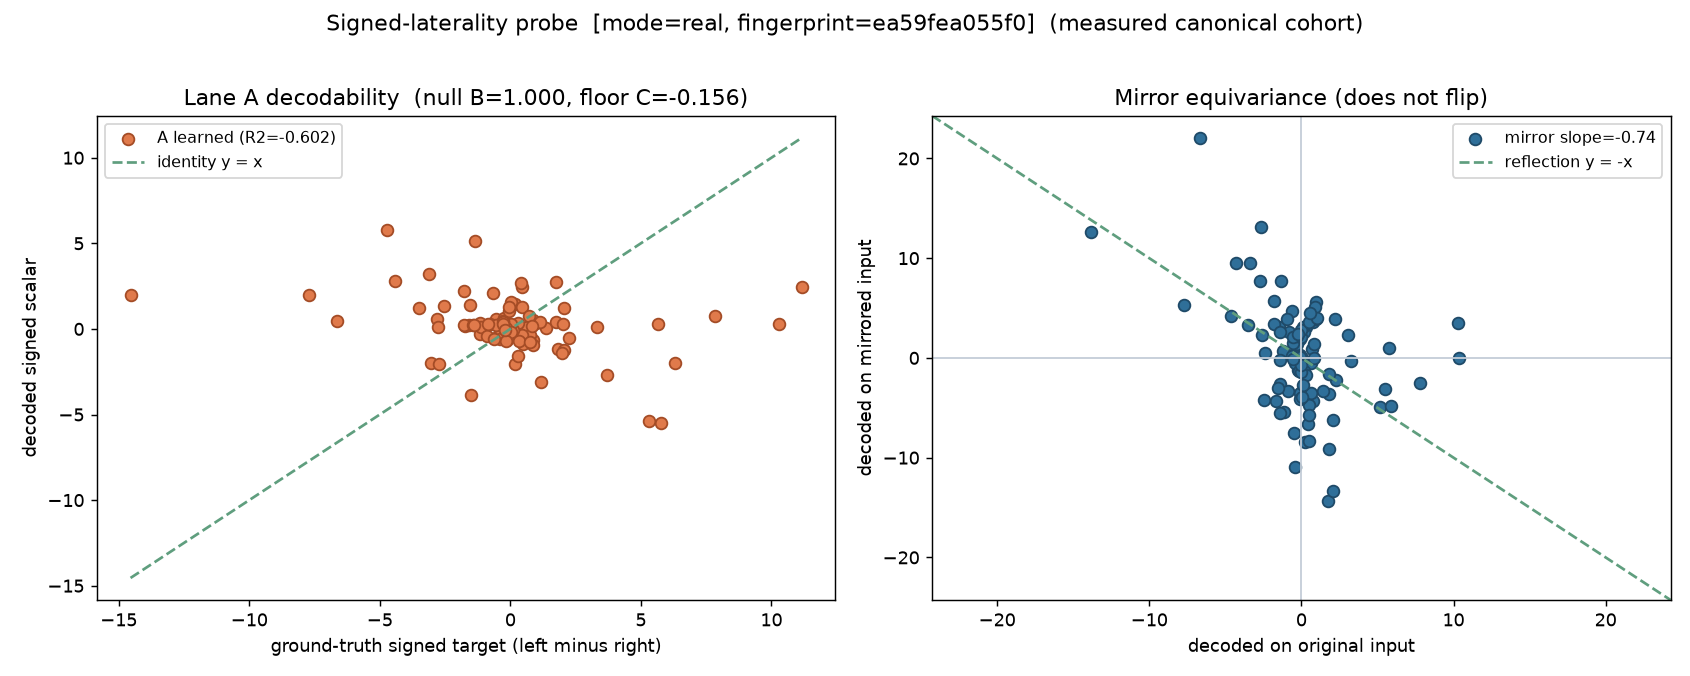

In [11]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image as IPythonImage, display

OUT_DIR = ARTIFACT_ROOT / MODE
OUT_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel 1: decodability
if HAVE_TORCH:
    preds = lanes["A_learned"]["preds"]
    ax[0].scatter(y, preds, s=42, c="#e07a4b", edgecolors="#a44c26", label=f"A learned (R2={lanes['A_learned']['r2']:.3f})")
    lo, hi = float(min(y.min(), preds[~np.isnan(preds)].min())), float(max(y.max(), preds[~np.isnan(preds)].max()))
    ax[0].plot([lo, hi], [lo, hi], "--", color="#5f9e7e", label="identity y = x")
    ax[0].set_title(f"Lane A decodability  (null B={lanes['B_raw_null']['r2']:.3f}, floor C={lanes['C_floor']['r2']:.3f})")
else:
    ax[0].text(0.5, 0.5, "Learned lanes need PyTorch", ha="center")
ax[0].set_xlabel("ground-truth signed target (left minus right)")
ax[0].set_ylabel("decoded signed scalar")
ax[0].legend(loc="upper left", fontsize=9)

# Panel 2: mirror
if mirror["available"]:
    ax[1].scatter(mirror["dec_orig"], mirror["dec_mir"], s=42, c="#2f6f99", edgecolors="#1f4a68",
                  label=f"mirror slope={mirror['slope']:+.2f}")
    lim = float(np.abs(np.concatenate([mirror["dec_orig"], mirror["dec_mir"]])).max()) * 1.1
    ax[1].plot([-lim, lim], [lim, -lim], "--", color="#5f9e7e", label="reflection y = -x")
    ax[1].axhline(0, color="#c4cdd8", lw=1); ax[1].axvline(0, color="#c4cdd8", lw=1)
    ax[1].set_xlim(-lim, lim); ax[1].set_ylim(-lim, lim)
    ax[1].set_title("Mirror equivariance " + ("(FLIPS)" if mirror["flips"] else "(does not flip)"))
else:
    ax[1].text(0.5, 0.5, "Mirror needs the encoder", ha="center")
ax[1].set_xlabel("decoded on original input"); ax[1].set_ylabel("decoded on mirrored input")
ax[1].legend(loc="upper right", fontsize=9)

figure_scope = "illustrative smoke fixture" if MODE == "smoke" else "measured canonical cohort"
fig.suptitle(
    f"Signed-laterality probe  [mode={MODE}, fingerprint={FINGERPRINT[:12]}]  ({figure_scope})",
    fontsize=12,
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = OUT_DIR / "idea5_signed_laterality_probe.png"
fig.savefig(fig_path, dpi=130)
print(f"saved figure: {fig_path}")
# Display the exact PNG that was written, even with the non-interactive Agg backend.
display(IPythonImage(filename=str(fig_path)))
plt.close(fig)

## 11. Persist the result bundle

**What we do.** Write a small JSON bundle holding the verdict, the per-lane R-squared and MAE, the
mirror slope, the checkpoint fingerprint, the fold count, and the cohort counts.

**Why a machine-readable record and not just prose.** Prose drifts and gets copied. A bundle does
not. This file is what the methodology document and the README point at, and it is the artifact any
later document should be checked against.

**What to look at in the output.** The written path, and then the echoed summary confirming
`fingerprint: ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95a98f28210b3042c4e4`,
`n_sequences: 96`, `n_sources: 18`, and `PRIMARY_VERDICT: INFORMATIVE NULL`.

**One trap worth knowing about.** The bundle is written under the artifact root resolved in
section 0, which is the `GAVD_ARTIFACT_DIR` tree. A stale file of the same name also exists under the
notebook's local default artifact path, and that stale copy carries the superseded `d0acc262`
fingerprint together with different lane numbers. The path resolution prefers the configured root, so
running code never picks it up, but a human reading files by hand can. The values in this notebook,
and in the bundle whose path is printed above, are the current ones.

**What we may conclude.** Only that the result is now recorded. Interpretation follows in sections 12
and 13.


In [12]:
bundle = {
    "notebook": "nb_05a_signed_laterality_probe",
    "mode": MODE,
    "fingerprint": FINGERPRINT,
    "n_sequences": int(len(records)),
    "n_sources": int(n_groups),
    "n_splits": int(n_splits),
    "condition_counts": meta.groupby("condition").size().to_dict(),
    "lanes": {k: {"r2": v["r2"], "mae": v["mae"]} for k, v in lanes.items()},
    "mirror": {"slope": mirror.get("slope"), "flips": mirror.get("flips")},
    "verdict": verdict,
    "transductive": True,
    "notes": "All results transductive; source video is the independent unit; folder labels are dataset annotations, not diagnoses.",
}
bundle_path = OUT_DIR / "idea5_signed_laterality_result.json"
bundle_path.write_text(json.dumps(bundle, indent=2))
print(f"wrote {bundle_path}")
print(json.dumps({k: bundle[k] for k in ("mode", "fingerprint", "n_sequences", "n_sources", "verdict")}, indent=2)[:900])

wrote /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/idea5_signed_laterality_result.json
{
  "mode": "real",
  "fingerprint": "ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95a98f28210b3042c4e4",
  "n_sequences": 96,
  "n_sources": 18,
  "verdict": {
    "mode": "real",
    "fingerprint": "ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95a98f28210b3042c4e4",
    "A_r2": -0.6021929001488207,
    "B_r2": 0.9999999989264047,
    "C_r2": -0.1561506987225285,
    "D_r2": -0.13077488186378972,
    "sign_consistency": 0.4444444444444444,
    "beats_floor_by_0.05": false,
    "reaches_80pct_of_null": false,
    "sign_consistent_75pct": false,
    "mirror_slope": -0.7408177852917672,
    "mirror_flips": false,
    "PRIMARY_VERDICT": "INFORMATIVE NULL",
    "D_control_ok": true
  }
}


## 12. Discussion: what the observed results mean

**What we do.** The next cell walks the measured result through eight steps, generated from the
`verdict` dictionary rather than typed by hand, so the prose cannot drift away from the numbers.

**Why generate the discussion instead of writing it.** Because a rerun with a different mode or
checkpoint would silently invalidate any hand-written paragraph. Reading values out of the same
dictionary that section 9 populated means the discussion is always about the run that actually
happened.

**What to look at in the output.** Steps 1 through 3 restate the question and read the four lane
scores. Step 4 walks each gate and the margin by which it failed. Step 5 covers the mirror. Step 6
explains why the clean Lane D control removes one alternative explanation without repairing any gate.
Step 7 is the limitations list, which is the part most worth reading slowly: the high-dimensional
problem, the transductive limitation, the fact that only a linear probe of one token construction was
tested, the near-circularity of Lane B, and the small number of independent source videos.

**How to read the saved output safely.** Lane C is -0.156, which is below zero but 0.446 above Lane A,
and measured sign consistency is 44.4 percent. The generated discussion below now states both
comparisons directly and uses the same values as the authoritative result bundle.

**What we may conclude.** Nothing beyond section 9. The discussion interprets; it does not add
evidence.


In [13]:
from IPython.display import Markdown, display

if HAVE_TORCH:
    a = verdict["A_r2"]
    b = verdict["B_r2"]
    c = verdict["C_r2"]
    d = verdict["D_r2"]
    floor_margin = 0.05
    null_fraction = 0.80
    sign_threshold = 0.75
    mirror_band = (-1.25, -0.8)
    floor_gap = a - c
    required_floor = c + floor_margin
    required_null = null_fraction * b
    discussion_markdown = f"""
### Step 1: restate the question

This experiment asks a narrow representation question: **can a simple weighted sum recover one left-minus-right motion number from features made by the already-trained encoder, on source videos that were withheld while that weighted sum was fitted?** This simple weighted sum is the linear probe or readout. The encoder is frozen, meaning none of its learned weights change here. The experiment is not asking whether raw pose coordinates contain laterality; Lane B checks that separately.

### Step 2: understand why four lanes are needed

- **Lane A, learned encoder:** this is the hypothesis under test. A strong result would mean the frozen learned features place the signed number where a simple readout can reach it.
- **Lane B, raw-coordinate ceiling:** this fits the same kind of simple readout directly to coordinate summaries. It checks that the target can in fact be recovered from the input information used to define it. Because the target is built as a linear sum of these signed movement summaries, an R-squared near 1 is expected. This lane validates the target and scoring path; it does not show that the encoder learned anything.
- **Lane C, untrained-encoder floor:** this uses an encoder with random, never-trained weights but the same shape as the learned encoder. It measures how much apparent prediction can arise from architecture, dimensionality, and accidental structure even without representation learning. Lane A must beat this floor by a fixed amount.
- **Lane D, side-agnostic nuisance control:** this deliberately forgets which joints are left and which are right by reducing them to global averages and standard deviations. If Lane D predicted well, the probe might be using overall movement size, video style, or pose-detector behavior instead of a genuine signed left/right distinction.

### Step 3: read the observed R-squared values

The measured values were Lane A `{a:.3f}`, Lane B `{b:.3f}`, Lane C `{c:.3f}`, and Lane D `{d:.3f}`. R-squared compares a model with the simple baseline of always predicting the held-out target average. A value of 1 means essentially perfect predictions, 0 means no improvement over repeatedly predicting that average, and a negative value means the model's squared errors are larger than the average-only baseline's errors. It does **not** mean the body moved in a negative direction. Lane A's `{a:.3f}` is therefore not merely small; on these source-disjoint predictions it is worse than predicting one constant average.

Lane B's `{b:.3f}` shows that the signed target is present in the raw coordinate construction. Lane C's `{c:.3f}` is below zero, so the untrained features also perform worse than the average-only baseline. Lane C still outperforms Lane A by `{c - a:.3f}`. That makes comparison with Lane C essential: it shows that representation training did not improve this linear readout over the untrained floor.

### Step 4: apply the three pre-registered gates

A gate is a minimum requirement fixed before the result was inspected. Each gate answers a different failure possibility:

1. **Gate 1: beat the untrained floor.** Purpose: show that training the encoder added useful linearly readable information beyond what random features already provide. Lane A needed at least `{required_floor:.3f}` because Lane C was `{c:.3f}` and the fixed improvement margin was `{floor_margin:.2f}`. Lane A was `{a:.3f}`, a gap of `{floor_gap:.3f}` relative to Lane C. It did not reach the minimum, so Gate 1 failed.
2. **Gate 2: approach the raw-coordinate ceiling.** Purpose: require the learned features to preserve a substantial part of a target that the original coordinates can express. Lane A needed at least `{required_null:.3f}`, which is `{null_fraction:.0%}` of Lane B. It reached `{a:.3f}`. It did not reach that minimum, so Gate 2 failed by a wide margin.
3. **Gate 3: preserve the positive-or-negative direction across held-out sources.** Purpose: prevent a favorable average score from hiding predictions whose left-versus-right direction changes unreliably from video to video. Correct sign was required on at least `{sign_threshold:.0%}` of held-out source videos. The observed fraction was `{verdict['sign_consistency']:.0%}`. It did not reach that minimum, so Gate 3 failed. A value this low is compatible with an unstable direction and does not support a dependable left-versus-right readout.

The primary claim requires all three gates together. Failing all three makes the informative-null verdict unambiguous under the registered rule.

### Step 5: inspect the mirror mechanism

For each sequence, **decoded-original** is Lane A's prediction from the ordinary pose. **Decoded-mirrored** is the same readout's prediction after horizontal `x` values are negated and all matching left/right landmark identities are swapped. No separate mirror decoder is trained. If an ordinary pose decodes to `+2`, its mirror should decode to about `-2`; if it decodes to `-3`, its mirror should decode to about `+3`. Across all sequences this equal-size, opposite-sign rule produces a decoded-mirrored-versus-decoded-original slope near `-1`, called antisymmetry. The accepted slope band was `{mirror_band}`. The observed slope was `{verdict['mirror_slope']:+.3f}`, outside that band, so the decoded axis did not reverse consistently enough to pass the mirror test. This agrees with the weak decodability result rather than rescuing it. The mirror probe was refitted on all available sources to inspect transformation geometry, so this is a secondary mechanism check, not a held-out prediction-performance estimate.

### Step 6: use the nuisance control correctly

Lane D was `{d:.3f}`, which satisfies the nuisance-control rule. Here, a nuisance is an unwanted shortcut such as total movement amount or video-specific style. Lane D is side-agnostic: it uses global averages and standard deviations but deliberately lacks explicit left-versus-right joint identity. A clean control means this deliberately handicapped lane stays near zero or far below the raw-coordinate reference, as expected. That rules out one pre-specified failure mode in which a supposedly signed result can be predicted without knowing left from right. A clean negative control does **not** turn Lane A into a positive result, prove the full pipeline artifact-free, or repair any failed gate; it only says the result is not the particular F4 nuisance pattern.

### Step 7: consider limitations before generalizing

- **High-dimensional limitation:** the learned feature vector has 1,152 columns for only `{len(y)}` sequences, drawn from even fewer independent source videos. In everyday terms, the probe has many possible numerical knobs but relatively few independent examples from which to set them. Several columns also carry nearly overlapping information; this is collinearity. Standardization, ridge regularization, and choosing the ridge strength only inside training folds reduce extreme fitting, but they cannot manufacture more independent videos. The recorded ill-conditioned-matrix warnings confirm that the numerical problem is difficult. Solver-sensitivity and dimensionality-reduction checks would show how much the exact score changes when that many-knobs problem is handled differently.
- **Transductive limitation:** the ridge folds hold out source videos from the probe, so those videos do not teach the final weighted sum. However, the frozen encoder was trained earlier on this same corpus. Imagine a student who studies all the cards before some are separated into a quiz: the final answer rule is tested on held-out cards, but the representation-maker has still seen the collection. The result therefore cannot support a claim about a completely unseen video, person, hospital, or dataset. A stronger test would train the encoder itself without the held-out people or sources.
- This is a linear probe of one chosen token construction. A null means the axis is not linearly exposed through this representation and readout; it does not prove that no nonlinear function, other layer, or alternative temporal summary could recover laterality.
- Lane B is almost exact partly because the target is explicitly constructed from the same family of raw signed-excursion measurements. It is a fair ceiling for this target, not an independent biological ground truth.
- Eighteen source videos remain a small independent-unit count. The experiment reports a registered threshold decision, not a precise population effect with stable confidence intervals.

### Step 8: identify the useful next experiments

The highest-value follow-ups are to repeat the probe with a numerically stable ridge solver and sensitivity analysis, test pre-registered alternative layers or temporal summaries without moving the current decision threshold, and fit the entire representation-learning pipeline inside source- or participant-disjoint folds. A real multi-view cohort would then test whether any recovered axis stays stable across viewpoints and flips under a genuine left/right view change.

### Discussion conclusion

The result is informative because the raw target is recoverable, the nuisance control behaves correctly, and the trained representation still fails every primary gate and the mirror test. The most direct interpretation is that this frozen checkpoint has **not organized the tested signed laterality quantity into a robust linearly accessible, reflection-antisymmetric axis**. This is a useful negative representation audit, not a clinical or universal statement about laterality.
"""
else:
    discussion_markdown = """
### Discussion unavailable

PyTorch was unavailable, so the learned, untrained, nuisance, and mirror lanes did not run. The raw-coordinate check alone cannot answer the signed-representation question.
"""

display(Markdown(discussion_markdown))



### Step 1: restate the question

This experiment asks a narrow representation question: **can a simple weighted sum recover one left-minus-right motion number from features made by the already-trained encoder, on source videos that were withheld while that weighted sum was fitted?** This simple weighted sum is the linear probe or readout. The encoder is frozen, meaning none of its learned weights change here. The experiment is not asking whether raw pose coordinates contain laterality; Lane B checks that separately.

### Step 2: understand why four lanes are needed

- **Lane A, learned encoder:** this is the hypothesis under test. A strong result would mean the frozen learned features place the signed number where a simple readout can reach it.
- **Lane B, raw-coordinate ceiling:** this fits the same kind of simple readout directly to coordinate summaries. It checks that the target can in fact be recovered from the input information used to define it. Because the target is built as a linear sum of these signed movement summaries, an R-squared near 1 is expected. This lane validates the target and scoring path; it does not show that the encoder learned anything.
- **Lane C, untrained-encoder floor:** this uses an encoder with random, never-trained weights but the same shape as the learned encoder. It measures how much apparent prediction can arise from architecture, dimensionality, and accidental structure even without representation learning. Lane A must beat this floor by a fixed amount.
- **Lane D, side-agnostic nuisance control:** this deliberately forgets which joints are left and which are right by reducing them to global averages and standard deviations. If Lane D predicted well, the probe might be using overall movement size, video style, or pose-detector behavior instead of a genuine signed left/right distinction.

### Step 3: read the observed R-squared values

The measured values were Lane A `-0.602`, Lane B `1.000`, Lane C `-0.156`, and Lane D `-0.131`. R-squared compares a model with the simple baseline of always predicting the held-out target average. A value of 1 means essentially perfect predictions, 0 means no improvement over repeatedly predicting that average, and a negative value means the model's squared errors are larger than the average-only baseline's errors. It does **not** mean the body moved in a negative direction. Lane A's `-0.602` is therefore not merely small; on these source-disjoint predictions it is worse than predicting one constant average.

Lane B's `1.000` shows that the signed target is present in the raw coordinate construction. Lane C's `-0.156` is below zero, so the untrained features also perform worse than the average-only baseline. Lane C still outperforms Lane A by `0.446`. That makes comparison with Lane C essential: it shows that representation training did not improve this linear readout over the untrained floor.

### Step 4: apply the three pre-registered gates

A gate is a minimum requirement fixed before the result was inspected. Each gate answers a different failure possibility:

1. **Gate 1: beat the untrained floor.** Purpose: show that training the encoder added useful linearly readable information beyond what random features already provide. Lane A needed at least `-0.106` because Lane C was `-0.156` and the fixed improvement margin was `0.05`. Lane A was `-0.602`, a gap of `-0.446` relative to Lane C. It did not reach the minimum, so Gate 1 failed.
2. **Gate 2: approach the raw-coordinate ceiling.** Purpose: require the learned features to preserve a substantial part of a target that the original coordinates can express. Lane A needed at least `0.800`, which is `80%` of Lane B. It reached `-0.602`. It did not reach that minimum, so Gate 2 failed by a wide margin.
3. **Gate 3: preserve the positive-or-negative direction across held-out sources.** Purpose: prevent a favorable average score from hiding predictions whose left-versus-right direction changes unreliably from video to video. Correct sign was required on at least `75%` of held-out source videos. The observed fraction was `44%`. It did not reach that minimum, so Gate 3 failed. A value this low is compatible with an unstable direction and does not support a dependable left-versus-right readout.

The primary claim requires all three gates together. Failing all three makes the informative-null verdict unambiguous under the registered rule.

### Step 5: inspect the mirror mechanism

For each sequence, **decoded-original** is Lane A's prediction from the ordinary pose. **Decoded-mirrored** is the same readout's prediction after horizontal `x` values are negated and all matching left/right landmark identities are swapped. No separate mirror decoder is trained. If an ordinary pose decodes to `+2`, its mirror should decode to about `-2`; if it decodes to `-3`, its mirror should decode to about `+3`. Across all sequences this equal-size, opposite-sign rule produces a decoded-mirrored-versus-decoded-original slope near `-1`, called antisymmetry. The accepted slope band was `(-1.25, -0.8)`. The observed slope was `-0.741`, outside that band, so the decoded axis did not reverse consistently enough to pass the mirror test. This agrees with the weak decodability result rather than rescuing it. The mirror probe was refitted on all available sources to inspect transformation geometry, so this is a secondary mechanism check, not a held-out prediction-performance estimate.

### Step 6: use the nuisance control correctly

Lane D was `-0.131`, which satisfies the nuisance-control rule. Here, a nuisance is an unwanted shortcut such as total movement amount or video-specific style. Lane D is side-agnostic: it uses global averages and standard deviations but deliberately lacks explicit left-versus-right joint identity. A clean control means this deliberately handicapped lane stays near zero or far below the raw-coordinate reference, as expected. That rules out one pre-specified failure mode in which a supposedly signed result can be predicted without knowing left from right. A clean negative control does **not** turn Lane A into a positive result, prove the full pipeline artifact-free, or repair any failed gate; it only says the result is not the particular F4 nuisance pattern.

### Step 7: consider limitations before generalizing

- **High-dimensional limitation:** the learned feature vector has 1,152 columns for only `96` sequences, drawn from even fewer independent source videos. In everyday terms, the probe has many possible numerical knobs but relatively few independent examples from which to set them. Several columns also carry nearly overlapping information; this is collinearity. Standardization, ridge regularization, and choosing the ridge strength only inside training folds reduce extreme fitting, but they cannot manufacture more independent videos. The recorded ill-conditioned-matrix warnings confirm that the numerical problem is difficult. Solver-sensitivity and dimensionality-reduction checks would show how much the exact score changes when that many-knobs problem is handled differently.
- **Transductive limitation:** the ridge folds hold out source videos from the probe, so those videos do not teach the final weighted sum. However, the frozen encoder was trained earlier on this same corpus. Imagine a student who studies all the cards before some are separated into a quiz: the final answer rule is tested on held-out cards, but the representation-maker has still seen the collection. The result therefore cannot support a claim about a completely unseen video, person, hospital, or dataset. A stronger test would train the encoder itself without the held-out people or sources.
- This is a linear probe of one chosen token construction. A null means the axis is not linearly exposed through this representation and readout; it does not prove that no nonlinear function, other layer, or alternative temporal summary could recover laterality.
- Lane B is almost exact partly because the target is explicitly constructed from the same family of raw signed-excursion measurements. It is a fair ceiling for this target, not an independent biological ground truth.
- Eighteen source videos remain a small independent-unit count. The experiment reports a registered threshold decision, not a precise population effect with stable confidence intervals.

### Step 8: identify the useful next experiments

The highest-value follow-ups are to repeat the probe with a numerically stable ridge solver and sensitivity analysis, test pre-registered alternative layers or temporal summaries without moving the current decision threshold, and fit the entire representation-learning pipeline inside source- or participant-disjoint folds. A real multi-view cohort would then test whether any recovered axis stays stable across viewpoints and flips under a genuine left/right view change.

### Discussion conclusion

The result is informative because the raw target is recoverable, the nuisance control behaves correctly, and the trained representation still fails every primary gate and the mirror test. The most direct interpretation is that this frozen checkpoint has **not organized the tested signed laterality quantity into a robust linearly accessible, reflection-antisymmetric axis**. This is a useful negative representation audit, not a clinical or universal statement about laterality.


## 13. Outcome of the signed-laterality experiment

**What we do.** Convert the pre-registered checks into one plain-language conclusion, again generated
from the current run's `verdict` dictionary so it stays accurate if the notebook is rerun.

**What to look at in the output.** The headline verdict line, then the six bullets carrying Lane A
-0.602, Lane B 1.000, Lane C -0.156, Lane D -0.131, sign consistency 44.4 percent, and mirror slope
-0.741. Then the licensed-conclusion paragraph, which is the sentence to quote if only one sentence
can be quoted.

**What this result licenses.** On this cohort of 96 sequences from 18 source videos, and under these
three pre-registered gates, the frozen representation does not make a signed left-minus-right
laterality axis linearly available above a raw-coordinate baseline, and does not reach an
untrained-encoder floor either. The decoded scalar also does not negate under the anatomical mirror.
The measurement was valid and the answer was no.

**What this result does not license.** It does not show that no side information exists anywhere in
the representation, because nonlinear readouts, other layers, and other temporal summaries were never
tested. It is not a statement about unseen videos, since the encoder trained on this corpus and every
score here is transductive. And it is not a clinical statement of any kind.

**Where this null is different from the two verdicts that follow it.** Keep these three apart; they
are three different epistemic states, not three ways of saying the same thing.

- **Idea 5, here, is an informative null.** The measurement was valid and the answer was no.
- **Idea 9 arm 1, in `nb_09a`, returns an artifact.** A side-blind control outscored the treatment
  there, so that lane is not admissible evidence about sides at all. The claim is withdrawn rather
  than answered, which is a *weaker* epistemic state than this null, not a stronger one.
- **Idea 9 arm 2, in the `new_nb_09_0x` series, returns no credit.** The effect there is real, large,
  and consistent on 18 of 18 source videos, but a pre-registered guardrail failed and its failure
  supplies a competing explanation, so the effect is not credited.

**The escape route this notebook leaves open, and who closes it.** This null was produced by a
*linear* readout with no structural constraint. Someone could reasonably object that a signed
quantity deserves a readout that is antisymmetric by construction, so that swapping left and right
necessarily negates its output. That objection is the reason Idea 9 arm 1 exists; it builds exactly
such a head, verifies its wiring at exactly -1, and the null survives.

**A forward pointer, not an Idea 5 result.** The measurement that later explains this null is the
between-source variance fraction of the signed target, roughly 7.5 percent against a pre-registered
30 percent, which means source-disjoint folds hold out almost all of the usable signal by
construction. That number was measured in `nb_09a`, not here. Attribute it to Idea 9 arm 1, and do
not cite it as an Idea 5 result.

**What comes next.** `nb_05b_reflection_reach_and_futures` rehearses this same decision rule on
simulated numbers and lays down an external multi-view scaffold; it produces no new verdict about the
checkpoint. `nb_09a` then closes the readout-shape escape route described above.


In [14]:
from IPython.display import Markdown, display

if HAVE_TORCH:
    failed_checks = [
        label for label, passed_check in [
            ("beat the untrained floor by at least 0.05 R-squared", verdict["beats_floor_by_0.05"]),
            ("reach at least 80% of the raw-coordinate ceiling", verdict["reaches_80pct_of_null"]),
            ("get the decoded sign right on at least 75% of held-out sources", verdict["sign_consistent_75pct"]),
        ] if not passed_check
    ]
    gate_text = (
        "The failed primary checks were: " + "; ".join(failed_checks) + "."
        if failed_checks else
        "All three primary checks passed."
    )
    mirror_text = (
        "inside" if verdict.get("mirror_flips") else "outside"
    )
    a_r2_meaning = (
        "worse than always predicting the held-out average"
        if verdict["A_r2"] < 0 else
        "no better than always predicting the held-out average"
        if abs(verdict["A_r2"]) < 1e-12 else
        "better than the held-out-average fallback, although the gates still determine the verdict"
    )
    d_control_text = (
        "passed: the side-agnostic summaries stayed low enough not to trigger the planned shortcut warning"
        if verdict["D_control_ok"] else
        "failed: side-agnostic summaries predicted too well, so an unwanted shortcut may explain the result"
    )
    mode_warning = (
        "**This is a smoke-mode plumbing result, not the frozen real-checkpoint result.**"
        if MODE == "smoke" else
        "**This is the measured result for the frozen real checkpoint and canonical cohort used by this run.**"
    )
    outcome_markdown = f"""
### Primary verdict: **{verdict['PRIMARY_VERDICT']}**

{mode_warning}

- **Learned Lane A:** R-squared `{verdict['A_r2']:.3f}`; this is {a_r2_meaning}.
- **Raw-coordinate Lane B:** R-squared `{verdict['B_r2']:.3f}`. This is the fair coordinate-level ceiling because the frozen target is constructed from signed coordinate excursions.
- **Untrained-encoder Lane C:** R-squared `{verdict['C_r2']:.3f}`.
- **Side-agnostic nuisance Lane D:** R-squared `{verdict['D_r2']:.3f}`; the control {d_control_text}.
- **Held-out-source sign consistency:** `{verdict['sign_consistency']:.1%}` of source videos had the correct positive-or-negative direction.
- **Mirror slope:** `{verdict['mirror_slope']:+.3f}`, which is {mirror_text} the pre-registered flip band `[-1.25, -0.8]`. A slope near `-1` would mean, for example, that decoded-original `+2` becomes decoded-mirrored `-2`. Mirror test passed: `{verdict['mirror_flips']}`.

A gate is a pre-agreed minimum requirement. {gate_text} The nuisance control stayed near zero, so this is not the specific artifact case in which side-agnostic pooling appears to recover a signed axis. A clean control removes that one shortcut explanation; it does not override a failed primary gate.

**Licensed conclusion.** Under this pre-registered linear probe, with whole source videos kept out of each probe-fitting fold, the frozen encoder does not expose the tested signed laterality axis strongly enough to pass the three gates. Its decoded-mirrored output also does not become the equal-size opposite of decoded-original. This is an informative null for the proposed simple linear signed-axis hypothesis: the planned test produced an interpretable negative answer. It does not prove that laterality is absent from the input, absent from every model layer, or impossible to recover with a more complicated rule. Because the encoder learned from this corpus before the probe split, the analysis is transductive and is not evidence about diagnosis or performance on a genuinely unseen patient or dataset.
"""
else:
    outcome_markdown = """
### Outcome unavailable

The encoder-dependent lanes and mirror test were skipped because PyTorch was unavailable. Only the raw-coordinate plumbing ran, so this notebook cannot issue the pre-registered signed-axis verdict.
"""

display(Markdown(outcome_markdown))



### Primary verdict: **INFORMATIVE NULL**

**This is the measured result for the frozen real checkpoint and canonical cohort used by this run.**

- **Learned Lane A:** R-squared `-0.602`; this is worse than always predicting the held-out average.
- **Raw-coordinate Lane B:** R-squared `1.000`. This is the fair coordinate-level ceiling because the frozen target is constructed from signed coordinate excursions.
- **Untrained-encoder Lane C:** R-squared `-0.156`.
- **Side-agnostic nuisance Lane D:** R-squared `-0.131`; the control passed: the side-agnostic summaries stayed low enough not to trigger the planned shortcut warning.
- **Held-out-source sign consistency:** `44.4%` of source videos had the correct positive-or-negative direction.
- **Mirror slope:** `-0.741`, which is outside the pre-registered flip band `[-1.25, -0.8]`. A slope near `-1` would mean, for example, that decoded-original `+2` becomes decoded-mirrored `-2`. Mirror test passed: `False`.

A gate is a pre-agreed minimum requirement. The failed primary checks were: beat the untrained floor by at least 0.05 R-squared; reach at least 80% of the raw-coordinate ceiling; get the decoded sign right on at least 75% of held-out sources. The nuisance control stayed near zero, so this is not the specific artifact case in which side-agnostic pooling appears to recover a signed axis. A clean control removes that one shortcut explanation; it does not override a failed primary gate.

**Licensed conclusion.** Under this pre-registered linear probe, with whole source videos kept out of each probe-fitting fold, the frozen encoder does not expose the tested signed laterality axis strongly enough to pass the three gates. Its decoded-mirrored output also does not become the equal-size opposite of decoded-original. This is an informative null for the proposed simple linear signed-axis hypothesis: the planned test produced an interpretable negative answer. It does not prove that laterality is absent from the input, absent from every model layer, or impossible to recover with a more complicated rule. Because the encoder learned from this corpus before the probe split, the analysis is transductive and is not evidence about diagnosis or performance on a genuinely unseen patient or dataset.


## Summary: what notebook 05a established

**What was established.**

1. The instrument is sound. The target is antisymmetric under the anatomical mirror by construction
   (section 1), the raw-coordinate lane recovers it at R-squared 1.000 (section 7), and the
   side-agnostic nuisance control stayed clean at -0.131 (section 9).
2. The treatment failed. On source-video-disjoint folds the frozen trained encoder scored -0.602,
   below its own untrained floor of -0.156 and below the side-blind pooling at -0.131.
3. All three pre-registered gates failed: floor margin -0.446 against a required +0.05, the raw-null
   requirement of 0.800 unmet, and sign consistency 44.4 percent against a required 75 percent.
4. The anatomical mirror does not negate the decoded scalar. The slope is -0.741, outside the
   pre-agreed `[-1.25, -0.8]` band.
5. The registered verdict is **INFORMATIVE NULL**: the measurement was valid and the answer was no.

**What remains open.**

- Whether a nonlinear readout, a different layer, or a different temporal summary could recover the
  axis. None of these were tested.
- Whether the null is caused by the *shape* of the readout rather than by the representation.
- Whether the cohort itself, at 18 independent source videos, can support a held-out-source claim of
  this kind at all.

**Where each open question is taken up.** The companion notebook
`nb_05b_reflection_reach_and_futures` rehearses this decision rule on simulated futures and scaffolds
an external multi-view arm; it adds no evidence about the checkpoint. `nb_09a` closes the
readout-shape question with an antisymmetric-by-construction head, and it is also where the cohort
question is answered. The `new_nb_09_0x` series then asks whether the symmetry can be trained in
rather than read out.

Every statement above is transductive, describes 18 source videos, and is not a clinical claim.
